# 07 - Normalize TopN Videos

Normalizes video files from the metadata produced by notebook 06:
- input: `merged_datasets/universal_metadata_topn_classes.csv`
- keeps original FPS
- resizes to `224x224`
- converts to grayscale
- saves new MP4s and a metadata CSV

Set `MAX_VIDEOS` to a small number for a quick test run.

In [37]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import Dict, Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.style.use("ggplot")

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.10.0


In [ ]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_topn_classes.csv"
OUTPUT_DIR = PROJECT_ROOT / "normalized_videos" / "topn_keepfps_224_gray"
OUTPUT_METADATA_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_topn_videos_normalized.csv"

TARGET_SIZE = (224, 224)
KEEP_ORIGINAL_FPS = True
COLOR_MODE = "grayscale"
CODEC = "mp4v"
OVERWRITE = True
MAX_WORKERS = 12
GENERATE_VIDEOS = False 

MAX_VIDEOS = None
SHUFFLE_BEFORE_LIMIT = True
RANDOM_SEED = 42

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_CSV}. Run notebook 06 first.")

print("INPUT_CSV:", INPUT_CSV)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("OUTPUT_METADATA_CSV:", OUTPUT_METADATA_CSV)
print("MAX_VIDEOS:", MAX_VIDEOS)
print("MAX_WORKERS:", MAX_WORKERS)
print("GENERATE_VIDEOS:", GENERATE_VIDEOS)

INPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_classes.csv
OUTPUT_DIR: C:\Users\kacpe\source\repos\szum\normalized_videos\topn_keepfps_224_gray
OUTPUT_METADATA_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_videos_normalized.csv
MAX_VIDEOS: None
MAX_WORKERS: 12
GENERATE_VIDEOS: False


In [39]:
def validate_input_df(df: pd.DataFrame) -> None:
    required_cols = ["video_path", "label"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def resolve_video_path(raw_path: str, project_root: Path) -> Path:
    p = Path(raw_path)
    if p.is_absolute():
        return p
    return project_root / p


def to_repo_path(absolute_path: Path, project_root: Path) -> str:
    try:
        return str(absolute_path.relative_to(project_root)).replace("\\", "/")
    except ValueError:
        return str(absolute_path).replace("\\", "/")


def safe_fps(cap: cv2.VideoCapture, metadata_fps: Any) -> float:
    fps_from_file = float(cap.get(cv2.CAP_PROP_FPS))
    if fps_from_file > 1e-6:
        return fps_from_file

    try:
        fps_meta = float(metadata_fps)
        if fps_meta > 1e-6:
            return fps_meta
    except Exception:
        pass

    return 30.0


def normalize_one_video(
    input_path: Path,
    output_path: Path,
    target_size: tuple[int, int],
    keep_original_fps: bool,
    metadata_fps: Any,
    codec: str,
    overwrite: bool,
    project_root: Path,
    generate_videos: bool = True,
) -> Dict[str, Any]:
    result: Dict[str, Any] = {
        "process_status": "ok",
        "process_error": "",
        "normalized_video_path": to_repo_path(output_path, project_root),
        "input_fps": np.nan,
        "normalized_fps": np.nan,
        "input_width": np.nan,
        "input_height": np.nan,
        "normalized_width": target_size[0],
        "normalized_height": target_size[1],
        "input_frame_count": 0,
        "normalized_frame_count": 0,
        "input_duration_sec": np.nan,
        "normalized_duration_sec": np.nan,
        "normalized_color_mode": COLOR_MODE,
    }

    if not input_path.exists():
        result["process_status"] = "missing_file"
        result["process_error"] = "Input file does not exist"
        return result

    if generate_videos and output_path.exists() and not overwrite:
        cap_existing = cv2.VideoCapture(str(output_path))
        if not cap_existing.isOpened():
            result["process_status"] = "write_error"
            result["process_error"] = "Output exists but cannot be opened"
            return result
        existing_fps = float(cap_existing.get(cv2.CAP_PROP_FPS))
        existing_frames = int(cap_existing.get(cv2.CAP_PROP_FRAME_COUNT))
        cap_existing.release()

        result["normalized_fps"] = existing_fps if existing_fps > 1e-6 else np.nan
        result["normalized_frame_count"] = existing_frames
        if existing_fps > 1e-6:
            result["normalized_duration_sec"] = existing_frames / existing_fps
        return result

    cap = cv2.VideoCapture(str(input_path))
    if not cap.isOpened():
        result["process_status"] = "read_error"
        result["process_error"] = "Cannot open input video"
        return result

    input_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    input_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    input_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    input_fps = safe_fps(cap, metadata_fps)

    result["input_width"] = input_width
    result["input_height"] = input_height
    result["input_frame_count"] = input_frames
    result["input_fps"] = input_fps
    if input_fps > 1e-6:
        result["input_duration_sec"] = input_frames / input_fps

    output_fps = input_fps if keep_original_fps else 30.0

    if not generate_videos:
        cap.release()
        result["normalized_frame_count"] = input_frames
        result["normalized_fps"] = output_fps
        if output_fps > 1e-6:
            result["normalized_duration_sec"] = input_frames / output_fps
        return result

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*codec)
    
    writer = cv2.VideoWriter(str(output_path), fourcc, output_fps, target_size)
    if not writer.isOpened():
        cap.release()
        result["process_status"] = "write_error"
        result["process_error"] = "Cannot open VideoWriter"
        return result

    out_frames = 0
    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray_resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
            # Keep MP4 compatibility by writing 3-channel grayscale.
            gray_bgr = cv2.cvtColor(gray_resized, cv2.COLOR_GRAY2BGR)
            writer.write(gray_bgr)
            out_frames += 1
    except Exception as exc:
        result["process_status"] = "read_error"
        result["process_error"] = f"Frame processing error: {exc}"
    finally:
        cap.release()
        writer.release()

    result["normalized_frame_count"] = out_frames
    result["normalized_fps"] = output_fps
    if output_fps > 1e-6:
        result["normalized_duration_sec"] = out_frames / output_fps

    if out_frames == 0 and result["process_status"] == "ok":
        result["process_status"] = "read_error"
        result["process_error"] = "No frames written"

    return result

In [40]:
df = pd.read_csv(INPUT_CSV)
validate_input_df(df)

print("Rows in input:", len(df))
print("Unique labels:", df["label"].nunique())

work_df = df.copy()
if SHUFFLE_BEFORE_LIMIT:
    work_df = work_df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

if MAX_VIDEOS is not None:
    work_df = work_df.head(int(MAX_VIDEOS)).copy()
    print(f"TEST MODE: processing first {len(work_df)} rows")
else:
    print(f"FULL MODE: processing all {len(work_df)} rows")

Rows in input: 1647
Unique labels: 30
FULL MODE: processing all 1647 rows


In [41]:
records = []

def process_row(idx: int, row: pd.Series) -> Dict[str, Any]:
    try:
        in_path = resolve_video_path(str(row["video_path"]), PROJECT_ROOT)
        label = str(row.get("label", "unknown"))

        out_name = f"{in_path.stem}_norm.mp4"
        out_path = OUTPUT_DIR / label / out_name

        r = normalize_one_video(
            input_path=in_path,
            output_path=out_path,
            target_size=TARGET_SIZE,
            keep_original_fps=KEEP_ORIGINAL_FPS,
            metadata_fps=row.get("fps", np.nan),
            codec=CODEC,
            overwrite=OVERWRITE,
            project_root=PROJECT_ROOT,
            generate_videos=GENERATE_VIDEOS,
        )

        merged = row.to_dict()
        merged.update(r)
        merged["_row_idx"] = idx
        return merged
    except Exception as exc:
        merged = row.to_dict()
        merged.update(
            {
                "process_status": "worker_error",
                "process_error": str(exc),
                "normalized_video_path": "",
                "_row_idx": idx,
            }
        )
        return merged

futures = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for idx, row in work_df.iterrows():
        futures.append(executor.submit(process_row, idx, row))

    done_count = 0
    total = len(futures)
    for future in as_completed(futures):
        records.append(future.result())
        done_count += 1
        if done_count % 25 == 0 or done_count == total:
            print(f"Processed {done_count}/{total}")

result_df = pd.DataFrame(records)
if "_row_idx" in result_df.columns:
    result_df = result_df.sort_values("_row_idx").drop(columns=["_row_idx"]).reset_index(drop=True)

status_counts = result_df["process_status"].value_counts(dropna=False)
print("\nProcess status counts:")
display(status_counts.to_frame("count"))

Processed 25/1647
Processed 50/1647
Processed 75/1647
Processed 100/1647
Processed 125/1647
Processed 150/1647
Processed 175/1647
Processed 200/1647
Processed 225/1647
Processed 250/1647
Processed 275/1647
Processed 300/1647
Processed 325/1647
Processed 350/1647
Processed 375/1647
Processed 400/1647
Processed 425/1647
Processed 450/1647
Processed 475/1647
Processed 500/1647
Processed 525/1647
Processed 550/1647
Processed 575/1647
Processed 600/1647
Processed 625/1647
Processed 650/1647
Processed 675/1647
Processed 700/1647
Processed 725/1647
Processed 750/1647
Processed 775/1647
Processed 800/1647
Processed 825/1647
Processed 850/1647
Processed 875/1647
Processed 900/1647
Processed 925/1647
Processed 950/1647
Processed 975/1647
Processed 1000/1647
Processed 1025/1647
Processed 1050/1647
Processed 1075/1647
Processed 1100/1647
Processed 1125/1647
Processed 1150/1647
Processed 1175/1647
Processed 1200/1647
Processed 1225/1647
Processed 1250/1647
Processed 1275/1647
Processed 1300/1647
Pr

,count
process_status,
ok,1647



Successful files: 1647
Failed files: 0


,label,input_fps,normalized_fps,input_width,input_height,normalized_width,normalized_height,input_duration_sec,normalized_duration_sec
0,learn,29.970030,29.970030,640,360,224,224,430.630200,430.630200
1,teacher,29.970091,29.970091,640,360,224,224,229.362000,229.362000
2,like,29.970030,29.970030,640,360,224,224,505.738567,505.738567
3,table,23.976024,23.976024,640,360,224,224,357.607250,357.607250
4,student,29.996001,29.996001,640,480,224,224,2.500333,2.500333
5,cousin,29.970030,29.970030,640,360,224,224,53.686967,53.686967
6,water,30.000000,30.000000,640,360,224,224,73.233333,73.233333
7,mother,29.970030,29.970030,1280,720,224,224,2.535867,2.535867
8,student,29.970091,29.970091,640,360,224,224,229.362000,229.362000
9,need,24.000000,24.000000,640,360,224,224,265.541667,265.541667


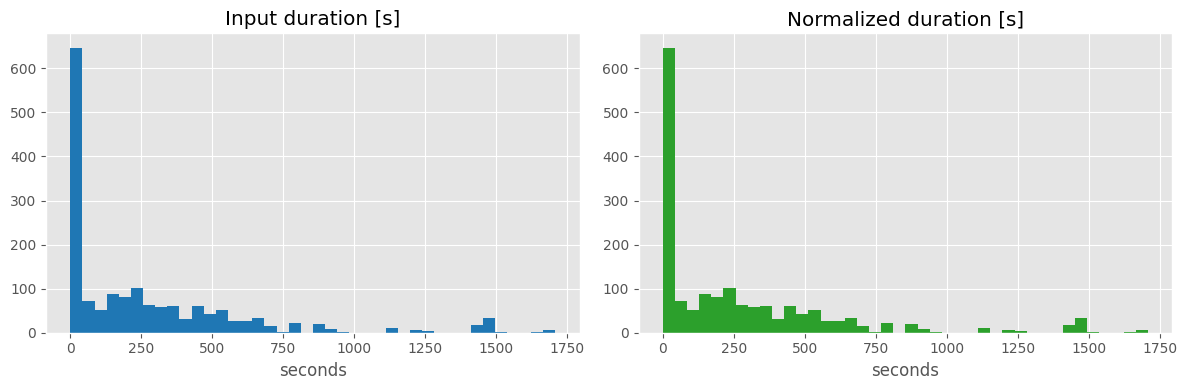

In [42]:
ok_df = result_df[result_df["process_status"] == "ok"].copy()

print("\nSuccessful files:", len(ok_df))
print("Failed files:", len(result_df) - len(ok_df))

if len(ok_df) > 0:
    compare_cols = [
        "label",
        "input_fps",
        "normalized_fps",
        "input_width",
        "input_height",
        "normalized_width",
        "normalized_height",
        "input_duration_sec",
        "normalized_duration_sec",
    ]
    display(ok_df[compare_cols].head(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ok_df["input_duration_sec"].dropna().hist(bins=40, ax=axes[0], color="#1f77b4")
    axes[0].set_title("Input duration [s]")
    axes[0].set_xlabel("seconds")

    ok_df["normalized_duration_sec"].dropna().hist(bins=40, ax=axes[1], color="#2ca02c")
    axes[1].set_title("Normalized duration [s]")
    axes[1].set_xlabel("seconds")

    plt.tight_layout()
    plt.show()

In [43]:
result_df.to_csv(OUTPUT_METADATA_CSV, index=False)

print("Saved metadata:", OUTPUT_METADATA_CSV)
print("Output videos root:", OUTPUT_DIR)

if len(ok_df) > 0:
    # Quick sanity check for a few successful outputs.
    sample_ok = ok_df.head(5)
    checks = []
    for p in sample_ok["normalized_video_path"]:
        vp = Path(str(p))
        checks.append((str(vp), vp.exists()))
    display(pd.DataFrame(checks, columns=["normalized_video_path", "exists"]))

Saved metadata: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_videos_normalized.csv
Output videos root: C:\Users\kacpe\source\repos\szum\normalized_videos\topn_keepfps_224_gray


,normalized_video_path,exists
0,normalized_videos\topn_keepfps_224_gray\learn\...,False
1,normalized_videos\topn_keepfps_224_gray\teache...,False
2,normalized_videos\topn_keepfps_224_gray\like\m...,False
3,normalized_videos\topn_keepfps_224_gray\table\...,False
4,normalized_videos\topn_keepfps_224_gray\studen...,False
